In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("benchmark_results_5_1_division equal.csv")
cuda = df[df["implementation"] == "CUDA"].copy()
omp = df[df["implementation"] == "OpenMP"].copy()


print (df.head())

resolution_pixels = {
    "720p": 1280*720, "1080p": 1920*1080,
    "1440p": 2560*1440, "2160p": 3840*2160
}

## Sequential vs OpenMP vs CUDA

In [ ]:
df["omp_threads"] = df["omp_threads"].fillna(-1)


# 1. Median ponavljanja za istu sliku
per_image = (
    df
    .groupby(["filter", "implementation", "resolution", "image_id", "omp_threads"])
    ["total_ms"]
    .median()
    .reset_index()
)

# 2. Median preko slika iste rezolucije
plot_data = (
    per_image
    .groupby(["filter", "implementation", "resolution", "omp_threads"])
    ["total_ms"]
    .median()
    .reset_index()
)

# Napravi citljiv label za x-osu: "Sequential", "CUDA", "OMP-1", "OMP-2", "OMP-4"...
def make_label(row):
    if row["implementation"] == "OpenMP":
        threads = int(row["omp_threads"]) if pd.notna(row["omp_threads"]) else 0
        return f"OMP-{threads}"
    return row["implementation"]

plot_data["label"] = plot_data.apply(make_label, axis=1)

# Redosled na x-osi: Sequential prvo, pa OMP po rastucem broju niti, pa CUDA na kraju
def sort_key(row):
    if row["implementation"] == "Sequential":
        return (0, 0)
    if row["implementation"] == "OpenMP":
        return (1, int(row["omp_threads"]) if pd.notna(row["omp_threads"]) else 0)
    return (2, 0)  # CUDA

plot_data["sort_key"] = plot_data.apply(sort_key, axis=1)

# ---------------------------------------------------------------------
# Graf 1: Poredjenje implementacija (Sequential vs OMP-N vs CUDA) po filteru/rezoluciji
# ---------------------------------------------------------------------

for filter_name in ["Invert", "Gauss", "Sobel", "Unsharp", "HistEqual"]:

    data = plot_data[plot_data["filter"] == filter_name]

    for resolution, group in data.groupby("resolution"):

        group = group.sort_values("sort_key")

        plt.figure(figsize=(9, 5))

        colors = ["#4C72B0" if impl == "Sequential"
                  else "#DD8452" if impl == "OpenMP"
                  else "#55A868"
                  for impl in group["implementation"]]

        bars = plt.bar(group["label"], group["total_ms"], color=colors)

        # log skala jer je CUDA reda velicine brzi od Sequential
        plt.yscale("log")

        plt.xlabel("Implementacija")
        plt.ylabel("Vreme izvrsavanja (ms, log skala)")
        plt.title(f"{filter_name} - {resolution}")
        plt.grid(axis="y", which="both", alpha=0.3)
        plt.xticks(rotation=45, ha="right")

        # ispisi tacnu vrednost iznad svakog bar-a
        for bar, val in zip(bars, group["total_ms"]):
            plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                      f"{val:.2f}", ha="center", va="bottom", fontsize=8)

        plt.tight_layout()
        plt.show()


## OMP Scaling

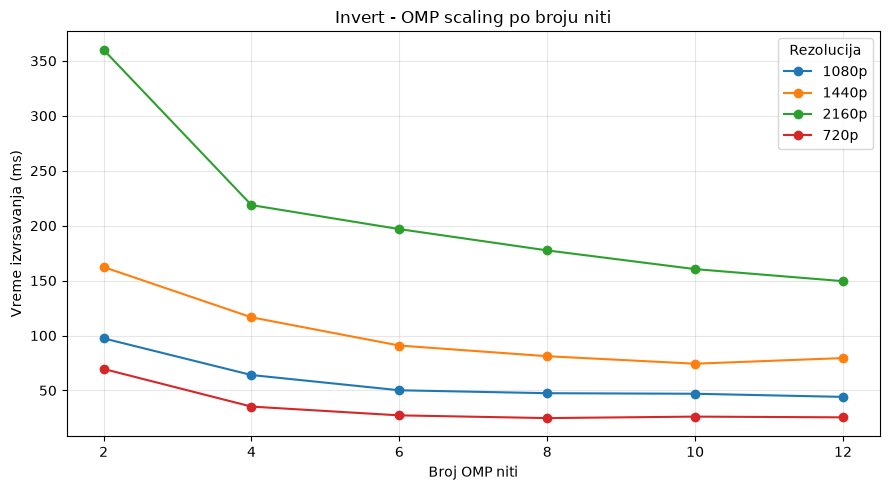

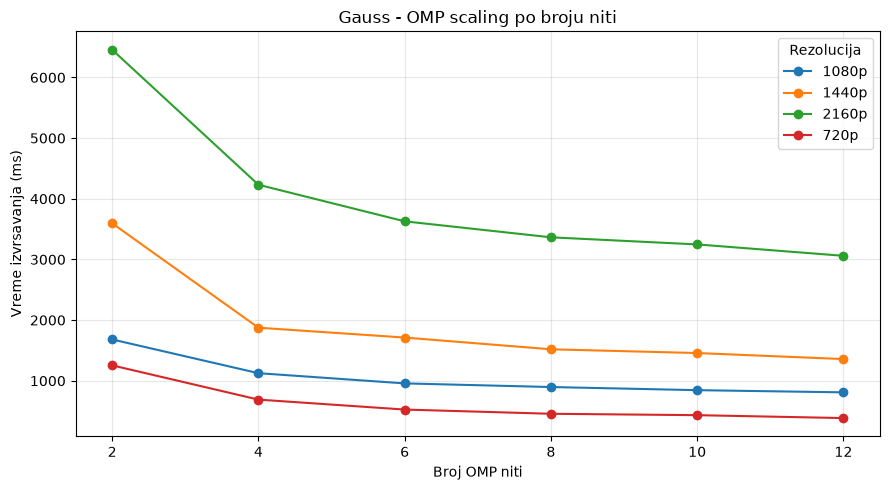

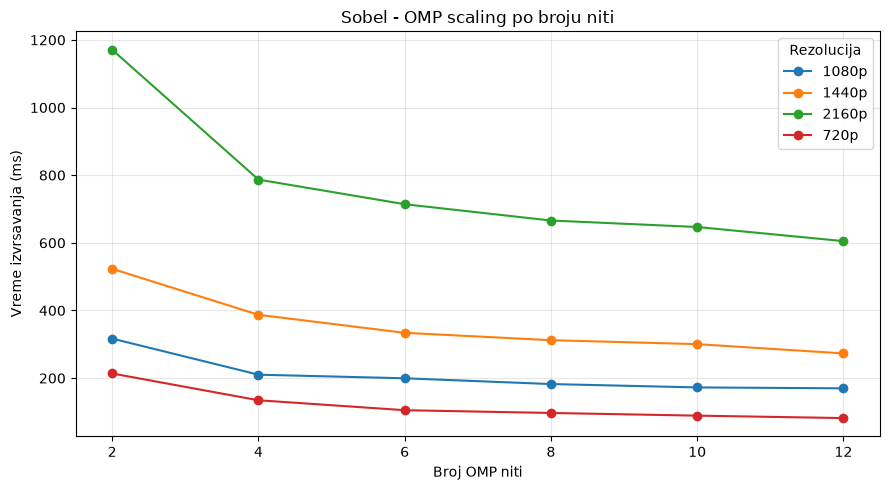

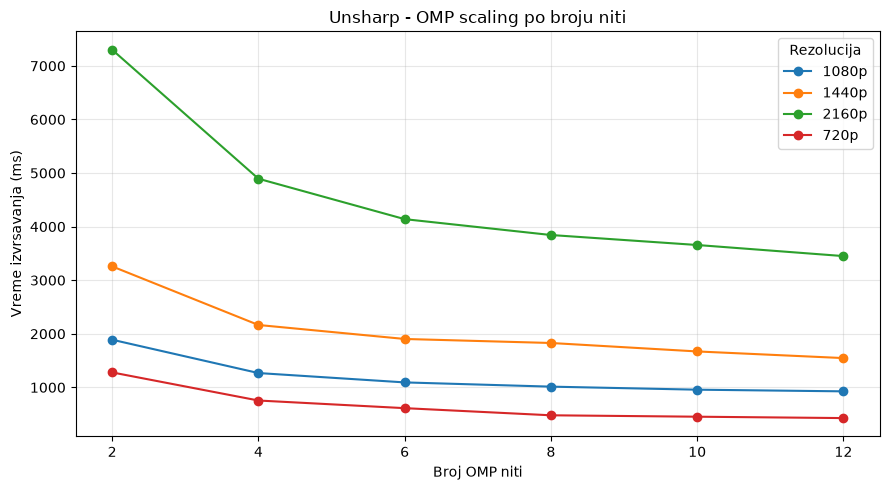

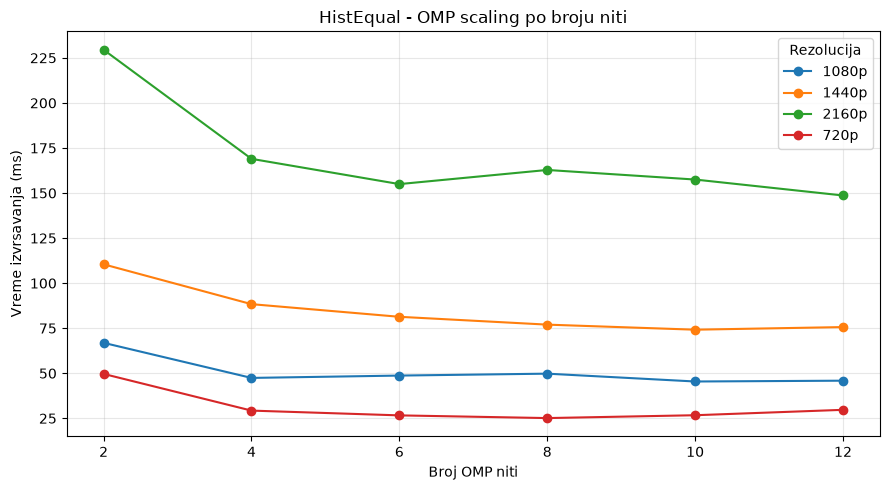

In [23]:

omp_only = plot_data[plot_data["implementation"] == "OpenMP"].copy()
omp_only["omp_threads"] = omp_only["omp_threads"].astype(int)

for filter_name in ["Invert", "Gauss", "Sobel", "Unsharp", "HistEqual"]:

    data = omp_only[omp_only["filter"] == filter_name]

    plt.figure(figsize=(9, 5))

    for resolution, group in data.groupby("resolution"):
        group = group.sort_values("omp_threads")
        plt.plot(group["omp_threads"], group["total_ms"], marker="o", label=resolution)

    plt.xlabel("Broj OMP niti")
    plt.ylabel("Vreme izvrsavanja (ms)")
    plt.title(f"{filter_name} - OMP scaling po broju niti")
    plt.legend(title="Rezolucija")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## Speedup OMP u odnosu na Seq

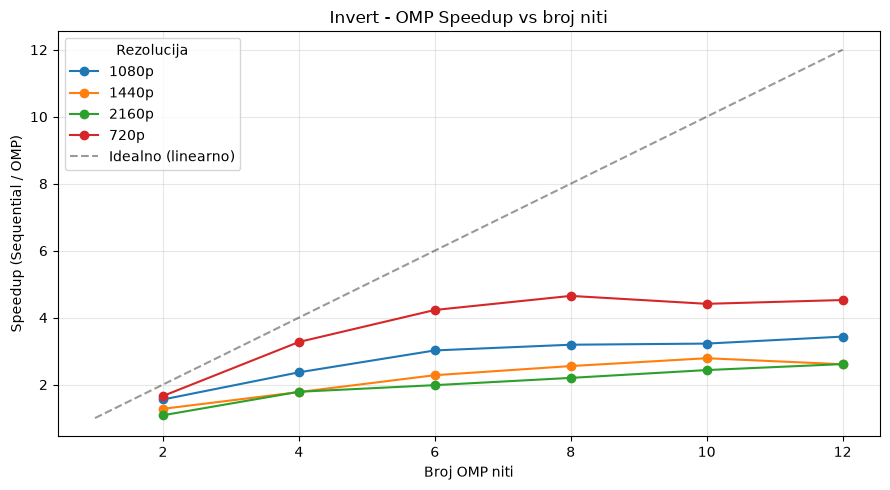

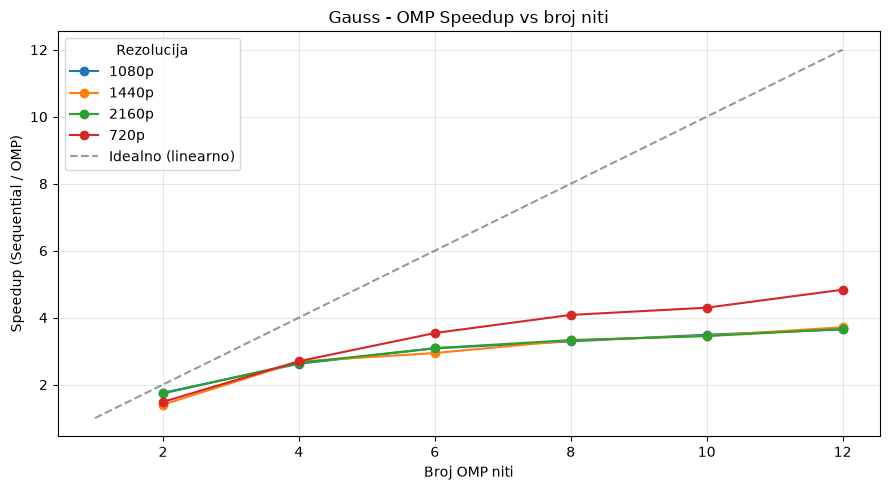

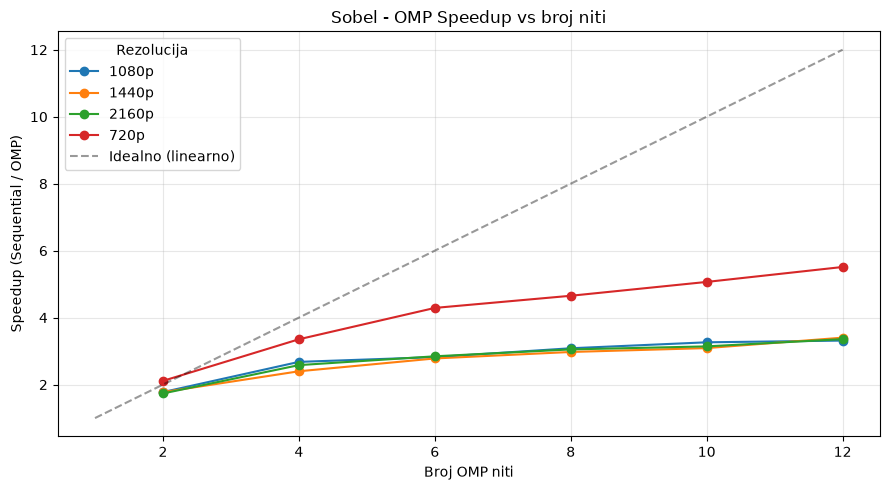

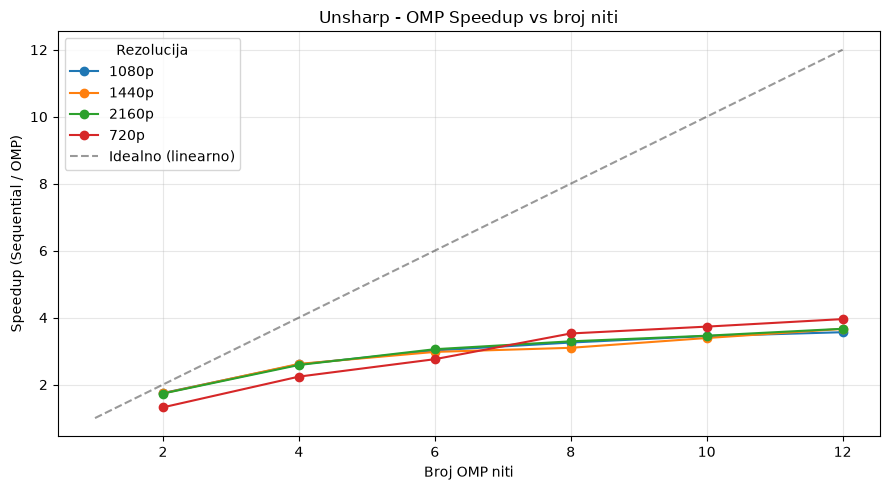

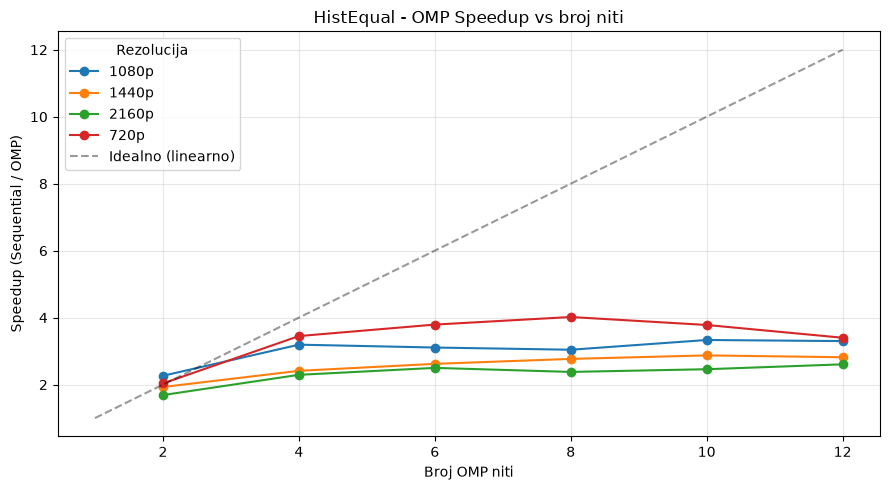

In [24]:
seq_only = plot_data[plot_data["implementation"] == "Sequential"][
    ["filter", "resolution", "total_ms"]
].rename(columns={"total_ms": "seq_ms"})

omp_speedup = omp_only.merge(seq_only, on=["filter", "resolution"])
omp_speedup["speedup"] = omp_speedup["seq_ms"] / omp_speedup["total_ms"]

for filter_name in ["Invert", "Gauss", "Sobel", "Unsharp", "HistEqual"]:

    data = omp_speedup[omp_speedup["filter"] == filter_name]

    plt.figure(figsize=(9, 5))

    for resolution, group in data.groupby("resolution"):
        group = group.sort_values("omp_threads")
        plt.plot(group["omp_threads"], group["speedup"], marker="o", label=resolution)

    # idealna linearna linija ubrzanja za referencu
    max_threads = int(data["omp_threads"].max())
    plt.plot([1, max_threads], [1, max_threads], "k--", alpha=0.4, label="Idealno (linearno)")

    plt.xlabel("Broj OMP niti")
    plt.ylabel("Speedup (Sequential / OMP)")
    plt.title(f"{filter_name} - OMP Speedup vs broj niti")
    plt.legend(title="Rezolucija")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## CUDA Bandwith Naive

In [ ]:
# pretpostavke po filteru: (broj_kanala, broj_citanja_po_pikselu)
filter_params = {
    "Invert":    (3, 1),
    "Gauss":     (3, 25),
    "Sobel":     (1, 9),
    "Unsharp":   (3, 25),   # priblizno, dominira gauss kernel
    "HistEqual": (1, 1),    # gruba aproksimacija, atomic pristupi komplikuju
}



def compute_bytes(row):
    pixels = resolution_pixels[row["resolution"]]
    channels, reads = filter_params[row["filter"]]
    return pixels * channels * (reads + 1)  # +1 za write

cuda["bytes"] = cuda.apply(compute_bytes, axis=1)
cuda["achieved_gbps"] = cuda["bytes"] / (cuda["kernel_ms"] / 1000) / 1e9

PEAK_BANDWIDTH_GBPS = 112.016
cuda["bandwidth_util_pct"] = cuda["achieved_gbps"] / PEAK_BANDWIDTH_GBPS * 100

print(cuda)
